In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Delinquency_prediction_dataset.xlsx to Delinquency_prediction_dataset.xlsx


In [ ]:
df = pd.read_excel("Delinquency_prediction_dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (500, 19)


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [ ]:
print("Columns in the dataset:")
for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Columns in the dataset:
1 - Customer_ID
2 - Age
3 - Income
4 - Credit_Score
5 - Credit_Utilization
6 - Missed_Payments
7 - Delinquent_Account
8 - Loan_Balance
9 - Debt_to_Income_Ratio
10 - Employment_Status
11 - Account_Tenure
12 - Credit_Card_Type
13 - Location
14 - Month_1
15 - Month_2
16 - Month_3
17 - Month_4
18 - Month_5
19 - Month_6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["Customer_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


In [ ]:
print("Delinquency distribution:")
print(df["Delinquent_Account"].value_counts())

print("\nDelinquency percentage:")
print(df["Delinquent_Account"].value_counts(normalize=True) * 100)

Delinquency distribution:
Delinquent_Account
0    420
1     80
Name: count, dtype: int64

Delinquency percentage:
Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64


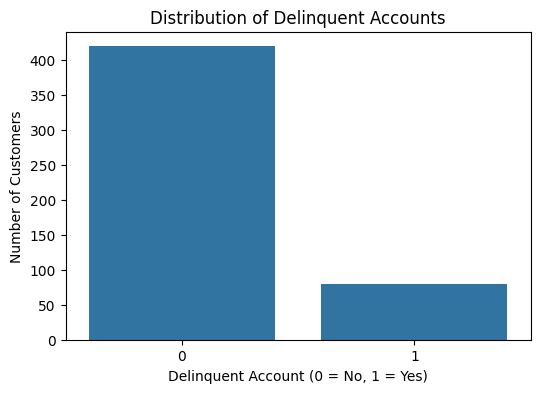

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Delinquent_Account", data=df)

plt.title("Distribution of Delinquent Accounts")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

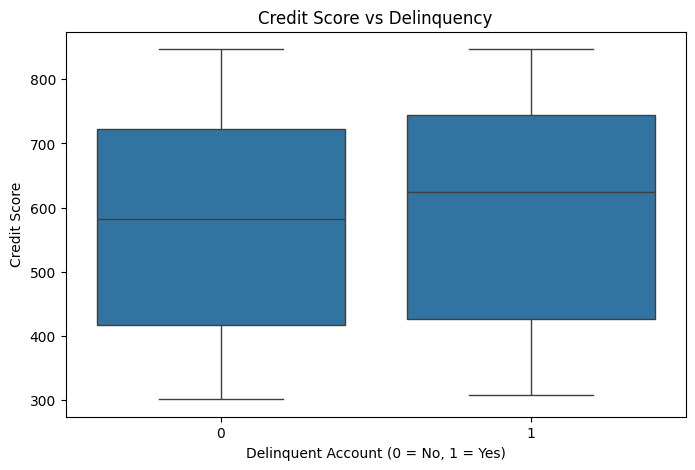

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Score",
    data=df
)

plt.title("Credit Score vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Credit Score")

plt.show()

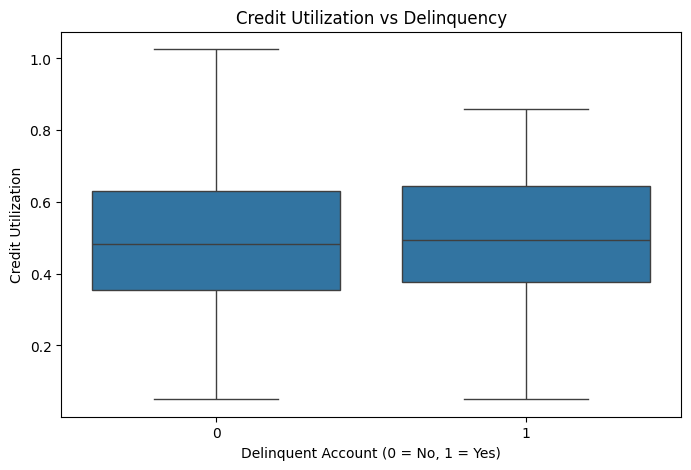

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Credit_Utilization",
    data=df
)

plt.title("Credit Utilization vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Credit Utilization")

plt.show()

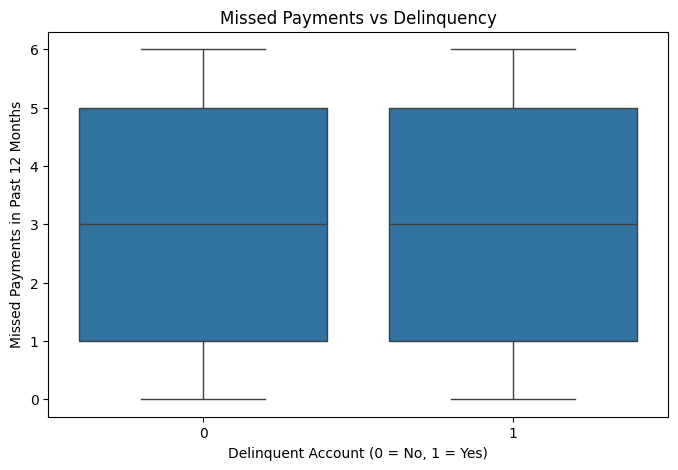

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Missed_Payments",
    data=df
)

plt.title("Missed Payments vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Missed Payments in Past 12 Months")

plt.show()

In [ ]:
payment_cols = [
    "Month_1", "Month_2", "Month_3",
    "Month_4", "Month_5", "Month_6"
]

payment_summary = df.groupby("Delinquent_Account")[payment_cols].mean()

print(payment_summary)

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
payment_cols = [
    "Month_1", "Month_2", "Month_3",
    "Month_4", "Month_5", "Month_6"
]

for col in payment_cols:
    print("\n", col)
    print(df[col].value_counts())


 Month_1
Month_1
On-time    177
Missed     164
Late       159
Name: count, dtype: int64

 Month_2
Month_2
Late       173
Missed     167
On-time    160
Name: count, dtype: int64

 Month_3
Month_3
Late       169
On-time    169
Missed     162
Name: count, dtype: int64

 Month_4
Month_4
Late       181
Missed     160
On-time    159
Name: count, dtype: int64

 Month_5
Month_5
Missed     187
On-time    162
Late       151
Name: count, dtype: int64

 Month_6
Month_6
Late       172
Missed     168
On-time    160
Name: count, dtype: int64


In [ ]:
payment_cols = [
    "Month_1", "Month_2", "Month_3",
    "Month_4", "Month_5", "Month_6"
]

payment_mapping = {
    "On-time": 0,
    "Late": 1,
    "Missed": 2
}

for col in payment_cols:
    df[col + "_Numeric"] = df[col].map(payment_mapping)

print("Payment history converted successfully!")

Payment history converted successfully!


In [ ]:
numeric_payment_cols = [col + "_Numeric" for col in payment_cols]

payment_summary = df.groupby("Delinquent_Account")[numeric_payment_cols].mean()

print(payment_summary)

                    Month_1_Numeric  Month_2_Numeric  Month_3_Numeric  \
Delinquent_Account                                                      
0                          0.988095         1.021429         0.980952   
1                          0.900000         0.975000         1.012500   

                    Month_4_Numeric  Month_5_Numeric  Month_6_Numeric  
Delinquent_Account                                                     
0                          0.980952         1.061905         1.021429  
1                          1.112500         0.987500         0.987500  


In [ ]:
df["Payment_History_Score"] = df[numeric_payment_cols].mean(axis=1)

print(
    df.groupby("Delinquent_Account")["Payment_History_Score"].mean()
)

Delinquent_Account
0    1.009127
1    0.995833
Name: Payment_History_Score, dtype: float64


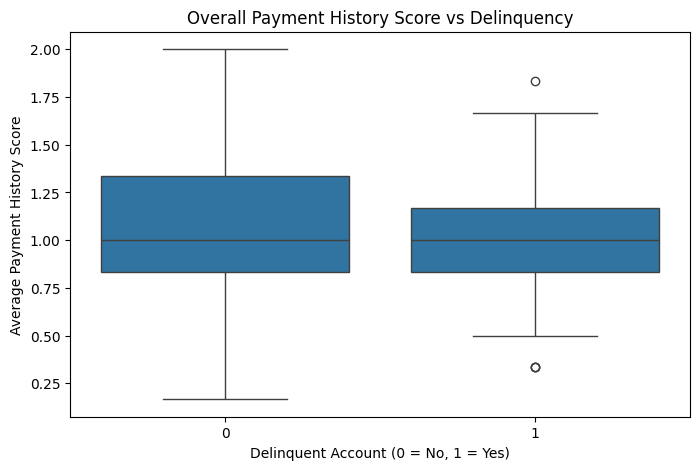

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Payment_History_Score",
    data=df
)

plt.title("Overall Payment History Score vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Average Payment History Score")

plt.show()

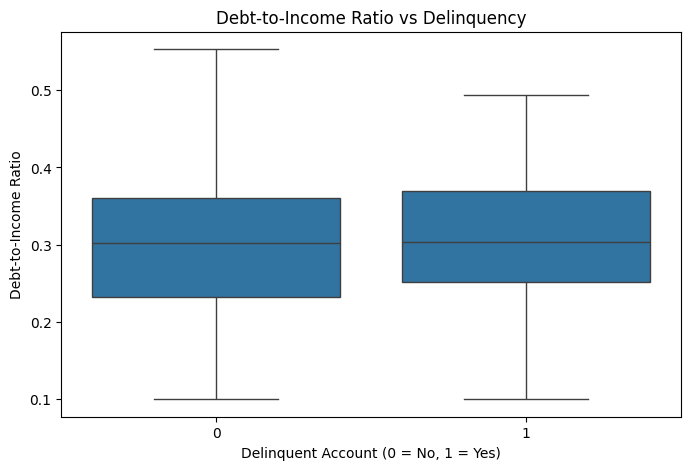

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Debt_to_Income_Ratio",
    data=df
)

plt.title("Debt-to-Income Ratio vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

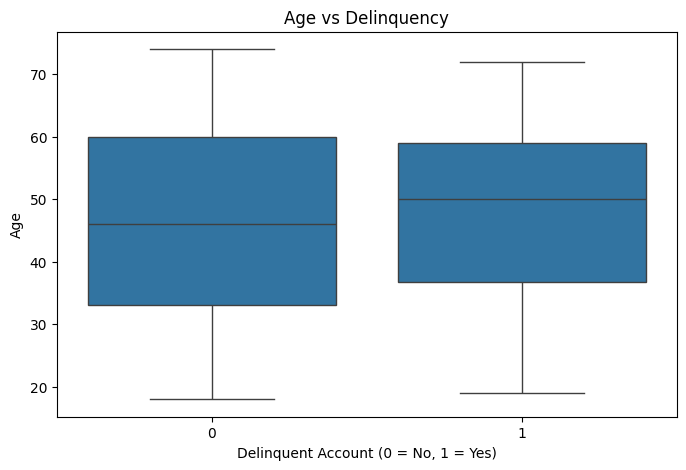

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Delinquent_Account",
    y="Age",
    data=df
)

plt.title("Age vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

In [ ]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "61+"]
)

age_risk = df.groupby("Age_Group", observed=False)["Delinquent_Account"].agg(
    ["count", "sum", "mean"]
)

age_risk["Delinquency_Rate_%"] = age_risk["mean"] * 100

print(age_risk)

           count  sum      mean  Delinquency_Rate_%
Age_Group                                          
18-30         94   15  0.159574           15.957447
31-45        138   17  0.123188           12.318841
46-60        138   30  0.217391           21.739130
61+          121   18  0.148760           14.876033


In [ ]:
print(df["Employment_Status"].value_counts(dropna=False))

Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64


In [ ]:
df["Employment_Status_Clean"] = df["Employment_Status"].replace({
    "Employed": "Employed",
    "employed": "Employed",
    "EMP": "Employed",
    "Self-employed": "Self-employed",
    "retired": "Retired",
    "Unemployed": "Unemployed"
})

print(df["Employment_Status_Clean"].value_counts())

Employment_Status_Clean
Employed         240
Unemployed        93
Retired           87
Self-employed     80
Name: count, dtype: int64


In [ ]:
employment_risk = df.groupby("Employment_Status_Clean")["Delinquent_Account"].agg(
    ["count", "sum", "mean"]
)

employment_risk["Delinquency_Rate_%"] = employment_risk["mean"] * 100

print(employment_risk)

                         count  sum      mean  Delinquency_Rate_%
Employment_Status_Clean                                          
Employed                   240   39  0.162500           16.250000
Retired                     87   10  0.114943           11.494253
Self-employed               80   13  0.162500           16.250000
Unemployed                  93   18  0.193548           19.354839


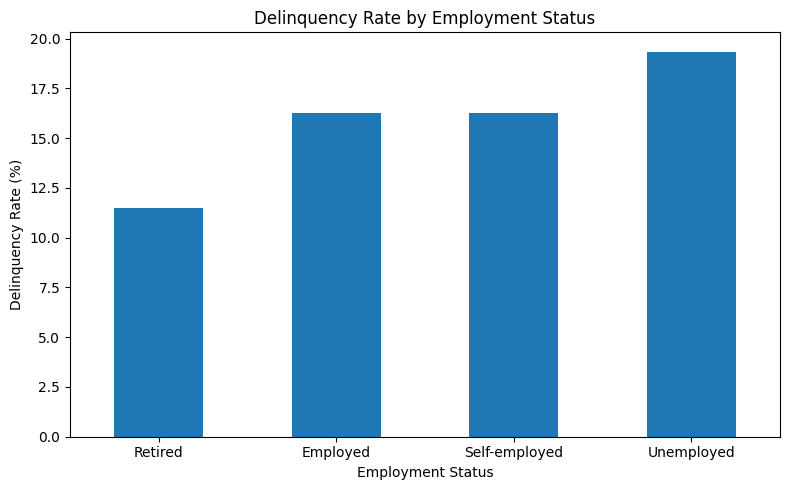

In [ ]:
plt.figure(figsize=(8,5))

employment_risk["Delinquency_Rate_%"].sort_values().plot(
    kind="bar"
)

plt.title("Delinquency Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Delinquency Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

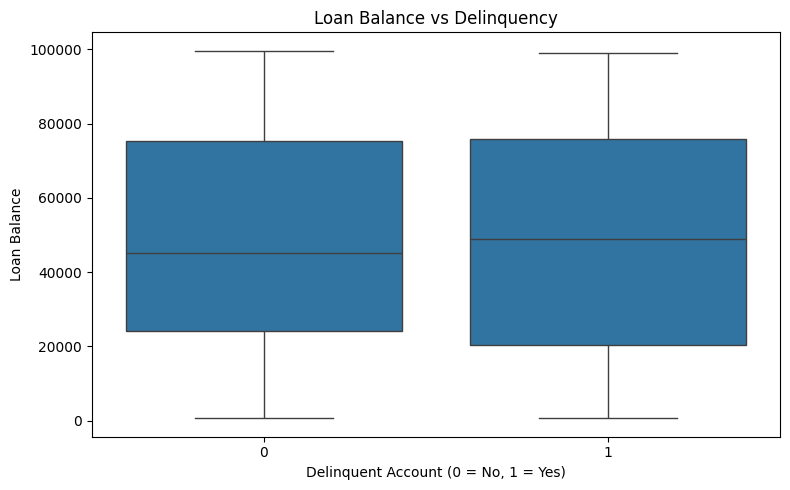

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delinquent_Account",
    y="Loan_Balance",
    data=df
)

plt.title("Loan Balance vs Delinquency")
plt.xlabel("Delinquent Account (0 = No, 1 = Yes)")
plt.ylabel("Loan Balance")
plt.tight_layout()
plt.show()

In [ ]:
df["Loan_Balance_Group"] = pd.qcut(
    df["Loan_Balance"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

loan_risk = df.groupby(
    "Loan_Balance_Group",
    observed=False
)["Delinquent_Account"].agg(["count", "sum", "mean"])

loan_risk["Delinquency_Rate_%"] = loan_risk["mean"] * 100

print(loan_risk)

                    count  sum      mean  Delinquency_Rate_%
Loan_Balance_Group                                          
Low                   118   21  0.177966           17.796610
Medium-Low            118   14  0.118644           11.864407
Medium-High           117   19  0.162393           16.239316
High                  118   19  0.161017           16.101695


In [ ]:
df["Credit_Utilization_Group"] = pd.qcut(
    df["Credit_Utilization"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

utilization_risk = df.groupby(
    "Credit_Utilization_Group",
    observed=False
)["Delinquent_Account"].agg(["count", "sum", "mean"])

utilization_risk["Delinquency_Rate_%"] = utilization_risk["mean"] * 100

print(utilization_risk)

                          count  sum   mean  Delinquency_Rate_%
Credit_Utilization_Group                                       
Low                         125   17  0.136                13.6
Medium-Low                  125   22  0.176                17.6
Medium-High                 125   20  0.160                16.0
High                        125   21  0.168                16.8


In [ ]:
# Make a separate copy for machine learning
model_df = df.copy()

print("Model dataset shape:", model_df.shape)
print(model_df.head())

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Delinquency_prediction_dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Delinquency_prediction_dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'Delinquency_prediction_dataset.xlsx'

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Delinquency_prediction_dataset.xlsx to Delinquency_prediction_dataset.xlsx


In [3]:
import pandas as pd

df = pd.read_excel("Delinquency_prediction_dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (500, 19)


In [4]:
model_df = df.copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (500, 19)


In [ ]:
model_df["Employment_Status"] = model_df["Employment_Status"].replace({
    "employed": "Employed",
    "EMP": "Employed",
    "retired": "Retired"
})

print(model_df["Employment_Status"].value_counts())

In [5]:
model_df["Employment_Status"] = model_df["Employment_Status"].replace({
    "employed": "Employed",
    "EMP": "Employed",
    "retired": "Retired"
})

print(model_df["Employment_Status"].value_counts())

Employment_Status
Employed         240
Unemployed        93
Retired           87
Self-employed     80
Name: count, dtype: int64


In [6]:
payment_mapping = {
    "On-time": 0,
    "Late": 1,
    "Missed": 2
}

payment_cols = [f"Month_{i}" for i in range(1, 7)]

for col in payment_cols:
    model_df[col] = model_df[col].map(payment_mapping)

print(model_df[payment_cols].head())

   Month_1  Month_2  Month_3  Month_4  Month_5  Month_6
0        1        1        2        1        2        1
1        2        2        1        2        0        0
2        2        1        1        0        2        1
3        1        2        1        2        1        1
4        2        0        2        1        1        1


In [7]:
y = model_df["Delinquent_Account"]

X = model_df.drop(
    columns=["Customer_ID", "Delinquent_Account"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 17)
y shape: (500,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 17)
Testing data: (100, 17)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "Age",
    "Income",
    "Credit_Score",
    "Credit_Utilization",
    "Missed_Payments",
    "Loan_Balance",
    "Debt_to_Income_Ratio",
    "Account_Tenure",
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

categorical_features = [
    "Employment_Status",
    "Credit_Card_Type",
    "Location"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Model pipeline created successfully!")

Model pipeline created successfully!


In [10]:
model.fit(X_train, y_train)

print("Model trained successfully! 🚀")

Model trained successfully! 🚀


In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100

Confusion Matrix:
[[84  0]
 [16  0]]
ROC-AUC: 0.453125


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# Train a second Logistic Regression with class balancing

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

print("Balanced model trained successfully! 🚀")

Balanced model trained successfully! 🚀


In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

Accuracy: 0.46

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.48      0.60        84
           1       0.12      0.38      0.18        16

    accuracy                           0.46       100
   macro avg       0.46      0.43      0.39       100
weighted avg       0.69      0.46      0.53       100

Confusion Matrix:
[[40 44]
 [10  6]]
ROC-AUC: 0.42261904761904767


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=5
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100

Confusion Matrix:
[[84  0]
 [16  0]]
ROC-AUC: 0.3244047619047619


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# Check how strongly numerical features relate to delinquency

numeric_check = model_df.select_dtypes(include=np.number)

correlation = numeric_check.corr()["Delinquent_Account"].sort_values(
    ascending=False
)

print("Correlation with Delinquent_Account:")
print(correlation)

Correlation with Delinquent_Account:
Delinquent_Account      1.000000
Month_4                 0.060377
Income                  0.045409
Credit_Score            0.034833
Debt_to_Income_Ratio    0.034386
Credit_Utilization      0.034224
Age                     0.022508
Month_3                 0.014217
Loan_Balance           -0.004320
Month_6                -0.015360
Month_2                -0.021050
Missed_Payments        -0.026478
Month_5                -0.032708
Month_1                -0.039127
Account_Tenure         -0.039829
Name: Delinquent_Account, dtype: float64


In [16]:
# Compare average values for delinquent vs non-delinquent customers

print(
    model_df.groupby("Delinquent_Account")[
        [
            "Age",
            "Income",
            "Credit_Score",
            "Credit_Utilization",
            "Missed_Payments",
            "Loan_Balance",
            "Debt_to_Income_Ratio",
            "Account_Tenure"
        ]
    ].mean()
)

                          Age         Income  Credit_Score  \
Delinquent_Account                                           
0                   46.107143  107306.943005    575.145933   
1                   47.100000  113902.013333    591.150000   

                    Credit_Utilization  Missed_Payments  Loan_Balance  \
Delinquent_Account                                                      
0                             0.488505         2.990476  48708.756281   
1                             0.506887         2.850000  48358.232877   

                    Debt_to_Income_Ratio  Account_Tenure  
Delinquent_Account                                        
0                               0.297445        9.842857  
1                               0.306301        9.200000  


In [17]:
# Check delinquency rate by payment-history category

for col in payment_cols:
    print("\n", col)
    print(
        model_df.groupby(col)["Delinquent_Account"]
        .agg(["count", "mean"])
    )


 Month_1
         count      mean
Month_1                 
0          177  0.197740
1          159  0.113208
2          164  0.164634

 Month_2
         count      mean
Month_2                 
0          160  0.175000
1          173  0.150289
2          167  0.155689

 Month_3
         count      mean
Month_3                 
0          169  0.159763
1          169  0.147929
2          162  0.172840

 Month_4
         count      mean
Month_4                 
0          159  0.113208
1          181  0.193370
2          160  0.168750

 Month_5
         count      mean
Month_5                 
0          162  0.160494
1          151  0.192053
2          187  0.133690

 Month_6
         count      mean
Month_6                 
0          160  0.181250
1          172  0.133721
2          168  0.166667


In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Prepare a simple numeric version for feature-information analysis
mi_df = model_df.copy()

# Encode categorical columns
for col in ["Employment_Status", "Credit_Card_Type", "Location"]:
    mi_df[col] = LabelEncoder().fit_transform(
        mi_df[col].astype(str)
    )

# Fill missing numerical values
mi_df = mi_df.fillna(mi_df.median(numeric_only=True))

X_mi = mi_df.drop(columns=["Customer_ID", "Delinquent_Account"])
y_mi = mi_df["Delinquent_Account"]

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_result = pd.Series(
    mi_scores,
    index=X_mi.columns
).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_result)

Mutual Information Scores:
Month_3                 0.041804
Month_5                 0.025502
Month_4                 0.024656
Account_Tenure          0.023526
Age                     0.003710
Debt_to_Income_Ratio    0.003216
Month_6                 0.001354
Income                  0.000000
Credit_Score            0.000000
Employment_Status       0.000000
Loan_Balance            0.000000
Credit_Utilization      0.000000
Missed_Payments         0.000000
Month_2                 0.000000
Month_1                 0.000000
Location                0.000000
Credit_Card_Type        0.000000
dtype: float64


In [19]:
print(model_df["Delinquent_Account"].value_counts())
print()
print(model_df.groupby("Delinquent_Account")["Missed_Payments"].describe())

Delinquent_Account
0    420
1     80
Name: count, dtype: int64

                    count      mean       std  min  25%  50%  75%  max
Delinquent_Account                                                    
0                   420.0  2.990476  1.940623  0.0  1.0  3.0  5.0  6.0
1                    80.0  2.850000  1.987938  0.0  1.0  3.0  5.0  6.0


In [20]:
print(
    pd.crosstab(
        model_df["Missed_Payments"],
        model_df["Delinquent_Account"],
        normalize="index"
    )
)

Delinquent_Account         0         1
Missed_Payments                       
0                   0.818182  0.181818
1                   0.814815  0.185185
2                   0.835443  0.164557
3                   0.884615  0.115385
4                   0.855422  0.144578
5                   0.779412  0.220588
6                   0.885246  0.114754


In [21]:
print(
    pd.crosstab(
        model_df["Credit_Utilization"] > 0.70,
        model_df["Delinquent_Account"],
        normalize="index"
    )
)

Delinquent_Account         0         1
Credit_Utilization                    
False               0.839907  0.160093
True                0.840580  0.159420


In [22]:
print(
    pd.crosstab(
        model_df["Missed_Payments"],
        model_df["Delinquent_Account"],
        normalize="index"
    ).round(3)
)

Delinquent_Account      0      1
Missed_Payments                 
0                   0.818  0.182
1                   0.815  0.185
2                   0.835  0.165
3                   0.885  0.115
4                   0.855  0.145
5                   0.779  0.221
6                   0.885  0.115


In [23]:
print(
    pd.crosstab(
        model_df["Credit_Utilization"] > 0.70,
        model_df["Delinquent_Account"],
        normalize="index"
    ).round(3)
)

Delinquent_Account      0      1
Credit_Utilization              
False               0.840  0.160
True                0.841  0.159


In [24]:
# Create aggregated payment-history features

model_df["Total_Late_Missed"] = (
    (model_df[payment_cols] >= 1).sum(axis=1)
)

model_df["Total_Missed"] = (
    (model_df[payment_cols] == 2).sum(axis=1)
)

model_df["Payment_Risk_Score"] = model_df[payment_cols].mean()

print(
    model_df[
        ["Total_Late_Missed", "Total_Missed", "Payment_Risk_Score"]
    ].head()
)

   Total_Late_Missed  Total_Missed  Payment_Risk_Score
0                  6             2                 NaN
1                  4             3                 NaN
2                  5             2                 NaN
3                  6             2                 NaN
4                  5             2                 NaN


In [25]:
print(
    model_df.groupby("Delinquent_Account")[
        ["Total_Late_Missed", "Total_Missed", "Payment_Risk_Score"]
    ].mean()
)

                    Total_Late_Missed  Total_Missed  Payment_Risk_Score
Delinquent_Account                                                     
0                            4.038095      2.016667                 NaN
1                            3.962500      2.012500                 NaN


In [26]:
model_df["Payment_Risk_Score"] = model_df[payment_cols].mean(axis=1)

print(
    model_df[
        ["Total_Late_Missed", "Total_Missed", "Payment_Risk_Score"]
    ].head()
)

   Total_Late_Missed  Total_Missed  Payment_Risk_Score
0                  6             2            1.333333
1                  4             3            1.166667
2                  5             2            1.166667
3                  6             2            1.333333
4                  5             2            1.166667


In [27]:
print(
    model_df.groupby("Delinquent_Account")[
        ["Total_Late_Missed", "Total_Missed", "Payment_Risk_Score"]
    ].mean().round(3)
)

                    Total_Late_Missed  Total_Missed  Payment_Risk_Score
Delinquent_Account                                                     
0                               4.038         2.017               1.009
1                               3.962         2.013               0.996


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("5-Fold ROC-AUC scores:")
print(cv_auc.round(3))

print("\nMean ROC-AUC:", round(cv_auc.mean(), 3))
print("Std ROC-AUC:", round(cv_auc.std(), 3))

5-Fold ROC-AUC scores:
[0.624 0.42  0.411 0.443 0.415]

Mean ROC-AUC: 0.463
Std ROC-AUC: 0.081


In [29]:
import joblib

# Save the trained model pipeline
joblib.dump(model, "geldium_credit_risk_model.pkl")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [30]:
def predict_customer(customer_data):

    # Convert input dictionary into DataFrame
    customer_df = pd.DataFrame([customer_data])

    # Convert payment history to numbers
    payment_mapping = {
        "On-time": 0,
        "Late": 1,
        "Missed": 2
    }

    for col in payment_cols:
        customer_df[col] = customer_df[col].map(payment_mapping)

    # Get delinquency probability
    probability = model.predict_proba(customer_df)[0][1]

    # Basic risk flag
    prediction = 1 if probability >= 0.50 else 0

    if probability < 0.30:
        risk = "Low"
    elif probability < 0.60:
        risk = "Medium"
    else:
        risk = "High"

    return {
        "Delinquency Probability": round(probability * 100, 2),
        "Prediction": "Delinquent" if prediction == 1 else "Non-Delinquent",
        "Risk Level": risk
    }

print("Prediction function created! 🚀")

Prediction function created! 🚀


In [31]:
test_customer = model_df.iloc[0].drop(
    labels=["Customer_ID", "Delinquent_Account"]
).to_dict()

result = predict_customer(test_customer)

print(result)

{'Delinquency Probability': np.float64(19.94), 'Prediction': 'Non-Delinquent', 'Risk Level': 'Low'}


In [32]:
# ============================================
# GELDIUM CREDIT RISK CALCULATOR
# ============================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- INPUT FIELDS ----------

age = widgets.IntText(
    value=35,
    description="Age:"
)

income = widgets.FloatText(
    value=60000,
    description="Income:"
)

credit_score = widgets.IntText(
    value=650,
    description="Credit Score:"
)

credit_utilization = widgets.FloatText(
    value=0.50,
    description="Credit Util:"
)

missed_payments = widgets.IntText(
    value=2,
    description="Missed Pay:"
)

loan_balance = widgets.FloatText(
    value=30000,
    description="Loan Balance:"
)

dti = widgets.FloatText(
    value=0.30,
    description="DTI:"
)

employment = widgets.Dropdown(
    options=["Employed", "Self-employed", "Unemployed", "Retired"],
    value="Employed",
    description="Employment:"
)

card_type = widgets.Dropdown(
    options=model_df["Credit_Card_Type"].dropna().unique().tolist(),
    description="Card Type:"
)

location = widgets.Dropdown(
    options=model_df["Location"].dropna().unique().tolist(),
    description="Location:"
)

account_tenure = widgets.FloatText(
    value=5,
    description="Tenure:"
)

# Payment history
month_widgets = []

for i in range(1, 7):
    w = widgets.Dropdown(
        options=["On-time", "Late", "Missed"],
        value="On-time",
        description=f"Month {i}:"
    )
    month_widgets.append(w)


# ---------- BUTTON ----------

predict_button = widgets.Button(
    description="🔍 Predict Credit Risk",
    button_style="primary"
)

output = widgets.Output()


# ---------- PREDICTION FUNCTION ----------

def run_prediction(button):

    with output:
        clear_output()

        customer = {
            "Age": age.value,
            "Income": income.value,
            "Credit_Score": credit_score.value,
            "Credit_Utilization": credit_utilization.value,
            "Missed_Payments": missed_payments.value,
            "Loan_Balance": loan_balance.value,
            "Debt_to_Income_Ratio": dti.value,
            "Employment_Status": employment.value,
            "Account_Tenure": account_tenure.value,
            "Credit_Card_Type": card_type.value,
            "Location": location.value
        }

        # Add payment history
        for i, w in enumerate(month_widgets, start=1):
            customer[f"Month_{i}"] = w.value

        result = predict_customer(customer)

        print("====================================")
        print("       CREDIT RISK RESULT")
        print("====================================")
        print()
        print(
            f"Delinquency Probability: "
            f"{result['Delinquency Probability']}%"
        )
        print()
        print(f"Prediction: {result['Prediction']}")
        print()
        print(f"Risk Level: {result['Risk Level']}")
        print()
        print("====================================")
        print("⚠️ Experimental model — not for")
        print("real-world credit decisions.")
        print("====================================")


predict_button.on_click(run_prediction)


# ---------- DISPLAY ----------

display(age)
display(income)
display(credit_score)
display(credit_utilization)
display(missed_payments)
display(loan_balance)
display(dti)
display(employment)
display(account_tenure)
display(card_type)
display(location)

for w in month_widgets:
    display(w)

display(predict_button)
display(output)

IntText(value=35, description='Age:')

FloatText(value=60000.0, description='Income:')

IntText(value=650, description='Credit Score:')

FloatText(value=0.5, description='Credit Util:')

IntText(value=2, description='Missed Pay:')

...

Dropdown(description='Month 4:', options=('On-time', 'Late', 'Missed'), value='On-time')

Dropdown(description='Month 5:', options=('On-time', 'Late', 'Missed'), value='On-time')

Dropdown(description='Month 6:', options=('On-time', 'Late', 'Missed'), value='On-time')

Button(button_style='primary', description='🔍 Predict Credit Risk', style=ButtonStyle())

Output()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Final model performance
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("===== FINAL MODEL PERFORMANCE =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))

===== FINAL MODEL PERFORMANCE =====
Accuracy : 0.84
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.453


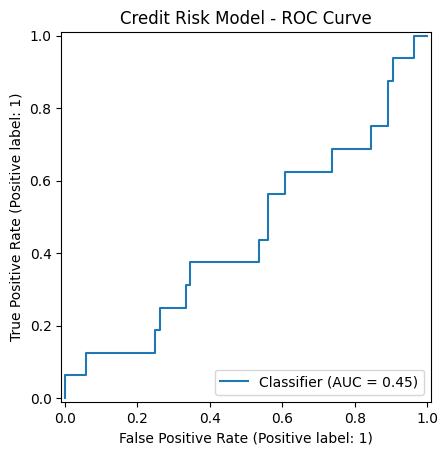

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("Credit Risk Model - ROC Curve")
plt.show()

In [35]:
print("===== FINAL MODEL RESULTS =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))

===== FINAL MODEL RESULTS =====
Accuracy : 0.84
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.453


In [36]:
from sklearn.linear_model import LogisticRegression

# Train a balanced Logistic Regression model
balanced_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train, y_train)

# Predictions
y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("===== BALANCED MODEL =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred_balanced), 3))
print("Precision:", round(precision_score(y_test, y_pred_balanced, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred_balanced, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_balanced, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_balanced), 3))

ValueError: could not convert string to float: 'Employed'

In [37]:
# Create a balanced version of the existing Logistic Regression model
balanced_model = model

balanced_model.set_params(classifier__class_weight="balanced")

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("===== BALANCED MODEL =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred_balanced), 3))
print("Precision:", round(precision_score(y_test, y_pred_balanced, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred_balanced, zero_division=0), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_balanced, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_balanced), 3))

===== BALANCED MODEL =====
Accuracy : 0.46
Precision: 0.12
Recall   : 0.375
F1 Score : 0.182
ROC-AUC  : 0.423


In [38]:
import joblib

# Save the final balanced model
joblib.dump(balanced_model, "Geldium_Credit_Risk_Final_Model.pkl")

print("✅ FINAL MODEL SAVED")
print("File: Geldium_Credit_Risk_Final_Model.pkl")
print("Model: Balanced Logistic Regression")
print("Purpose: Credit delinquency risk prediction")

✅ FINAL MODEL SAVED
File: Geldium_Credit_Risk_Final_Model.pkl
Model: Balanced Logistic Regression
Purpose: Credit delinquency risk prediction


In [39]:
from google.colab import files

files.download("Geldium_Credit_Risk_Final_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>